In [1]:
#Importing Pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Reading the csv file and storing it in df
df = pd.read_csv('Salary_dataset.csv')

In [3]:
df.shape

(30, 3)

This dataset has 30 rows and 3 columns

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


Since, we do not need the first unnamed column. Let us remove it.

In [5]:
df = df.drop(columns=['Unnamed: 0'])

In [6]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


Let us divide the dataframe into x and y features

In [7]:
# x = df.iloc[:,[0]]
# y = df.iloc[:,[-1]]
x= df[["YearsExperience"]]
y = df[["Salary"]]

In [8]:
y.head()

,Salary
0,39344.0
1,46206.0
2,37732.0
3,43526.0
4,39892.0


In [9]:
x.head()

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3


Divide the dataset into train and test splits

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [11]:
len(x_train)

24

In [12]:
len(x_test)

6

In [13]:
len(y_train)

24

In [14]:
len(y_test)

6

Let us Scale these features using the standard scalar

In [15]:
#Feature Scaling using Standard Scaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

Train the model

In [16]:
#Train the model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[26822.75]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[77165.08]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.9]


In [17]:
#Predictions
y_pred = regressor.predict(x_test)

In [18]:
y_pred

array([[ 54331.88192488],
       [ 62719.58856472],
       [ 60855.65375587],
       [ 92542.54550637],
       [107454.0239772 ],
       [ 46876.14268947]])

In [19]:
y_test = np.array(y_test)

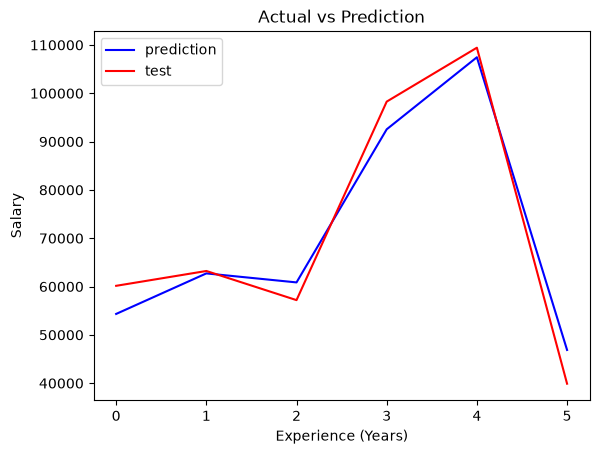

In [20]:
#Plotting of y_test vs y_pred

plt.plot(y_pred, color='blue', label='prediction')
plt.plot(y_test, color='red', label='test')
plt.title('Actual vs Prediction')
plt.ylabel('Salary')
plt.xlabel('Experience (Years)')
plt.legend()
plt.show()

Evaluation the model performance

In [21]:
#Model Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

print('mae:', mean_absolute_error(y_test,y_pred))
print('rmse:', root_mean_squared_error(y_test,y_pred))
print('r2_score:', r2_score(y_test,y_pred))

mae: 4112.959412027726
rmse: 4709.719971823454
r2_score: 0.9625816901813793
